In [ ]:
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import glob
import random
from typing import List
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CROP_SIZE = 33
lr = 1e-5
num_epochs = 10000
batch_size = 4


In [44]:
def random_crop_pair(lr: np.ndarray, hr: np.ndarray, crop_size=33):
    h, w = lr.shape

    if h < crop_size or w < crop_size:
        raise ValueError("Image too small for cropping.")

    x = random.randint(0, w - crop_size)
    y = random.randint(0, h - crop_size)

    lr_crop = lr[y:y+crop_size, x:x+crop_size]
    hr_crop = hr[y:y+crop_size, x:x+crop_size]

    return lr_crop, hr_crop

def make_low_resolution(img: Image.Image, scale: int) -> Image.Image:
    w, h = img.size

    low_w = w // scale
    low_h = h // scale

    img_down = img.resize((low_w, low_h), Image.BILINEAR)

    img_up = img_down.resize((w, h), Image.BILINEAR)

    return img_up
    
def rgb_to_y(img: Image.Image) -> np.ndarray:
    ycbcr = img.convert("YCbCr")
    y, _, _ = ycbcr.split()
    return np.array(y, dtype=np.float32)

In [46]:
class OnFlyDataset(Dataset):
    def __init__(self, root_dir: str, scale: int = None, seed=None):
        self.root_dir = root_dir
        self.scale = scale
        self.seed = seed

        exts = ("*.png",)
        image_paths: List[str] = []
        for ext in exts:
            image_paths.extend(glob.glob(os.path.join(root_dir, ext)))

        self.image_paths = sorted(image_paths)

        if len(self.image_paths) == 0:
            raise RuntimeError(f"No images found in {root_dir}")


    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        if self.seed is not None:
            random.seed(self.seed + idx)

        scale = self.scale if self.scale is not None else random.choice([2, 3])

        path = self.image_paths[idx]

        hr_img = Image.open(path).convert("RGB")

        lr_img = make_low_resolution(hr_img, scale)

        hr_y = rgb_to_y(hr_img)
        lr_y = rgb_to_y(lr_img)

        lr_crop, hr_crop = random_crop_pair(lr_y, hr_y, crop_size=CROP_SIZE)

        lr_tensor = torch.from_numpy(lr_crop).unsqueeze(0) / 255.0
        hr_tensor = torch.from_numpy(hr_crop).unsqueeze(0) / 255.0

        return lr_tensor, hr_tensor

In [38]:
class SuperResolutionSRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)

    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.conv3(x)
        return x


model = SuperResolutionSRCNN().to(device)
print(model)

SuperResolutionSRCNN(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu2): ReLU(inplace=True)
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


In [47]:
dataset = OnFlyDataset("./T91", scale=2)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

epoch_losses = []

for epoch in range(num_epochs):
    model.train()

    lr_batch, hr_batch = next(iter(loader))

    lr_batch = lr_batch.to(device)
    hr_batch = hr_batch.to(device)

    optimizer.zero_grad()
    pred = model(lr_batch)
    loss = criterion(pred, hr_batch)
    loss.backward()
    optimizer.step()

    epoch_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{num_epochs} - loss: {loss.item():.6f}")

Epoch 1/2000 - loss: 0.335139
Epoch 2/2000 - loss: 0.233595
Epoch 3/2000 - loss: 0.234847
Epoch 4/2000 - loss: 0.242458
Epoch 5/2000 - loss: 0.108707
Epoch 6/2000 - loss: 0.214675
Epoch 7/2000 - loss: 0.130801
Epoch 8/2000 - loss: 0.155564
Epoch 9/2000 - loss: 0.152694
Epoch 10/2000 - loss: 0.254066
Epoch 11/2000 - loss: 0.245878
Epoch 12/2000 - loss: 0.127520
Epoch 13/2000 - loss: 0.131875
Epoch 14/2000 - loss: 0.163481
Epoch 15/2000 - loss: 0.154885
Epoch 16/2000 - loss: 0.152088
Epoch 17/2000 - loss: 0.210814
Epoch 18/2000 - loss: 0.125424
Epoch 19/2000 - loss: 0.150404
Epoch 20/2000 - loss: 0.183796
Epoch 21/2000 - loss: 0.161362
Epoch 22/2000 - loss: 0.156122
Epoch 23/2000 - loss: 0.114819
Epoch 24/2000 - loss: 0.103240
Epoch 25/2000 - loss: 0.225847
Epoch 26/2000 - loss: 0.079013
Epoch 27/2000 - loss: 0.203290
Epoch 28/2000 - loss: 0.170262
Epoch 29/2000 - loss: 0.127950
Epoch 30/2000 - loss: 0.162204
Epoch 31/2000 - loss: 0.052952
Epoch 32/2000 - loss: 0.120644
Epoch 33/2000 - l

KeyboardInterrupt: 

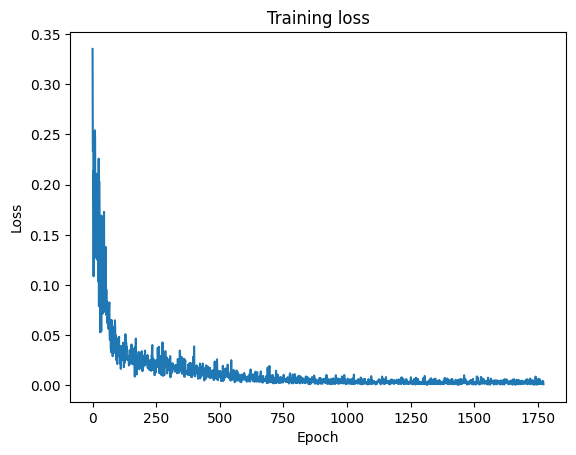

In [48]:

plt.plot(epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()


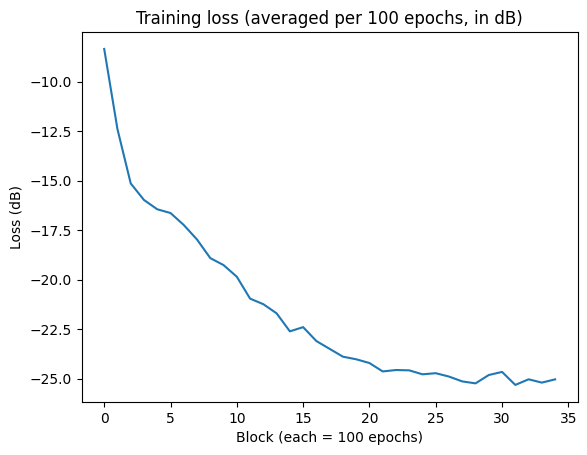

In [ ]:

epoch_losses = np.array(epoch_losses)

N = 50  # group size
trim = len(epoch_losses) // N * N
loss_avg = epoch_losses[:trim].reshape(-1, N).mean(axis=1)

eps = 1e-12
loss_db = 10 * np.log10(loss_avg + eps)

plt.plot(loss_db)
plt.xlabel("Block (each = 100 epochs)")
plt.ylabel("Loss (dB)")
plt.title("Training loss (averaged per 100 epochs, in dB)")
plt.show()

Using test image: ./T91_test/tt15.png
Scale 2: MSE on Y = 0.006617
Scale 3: MSE on Y = 0.007645


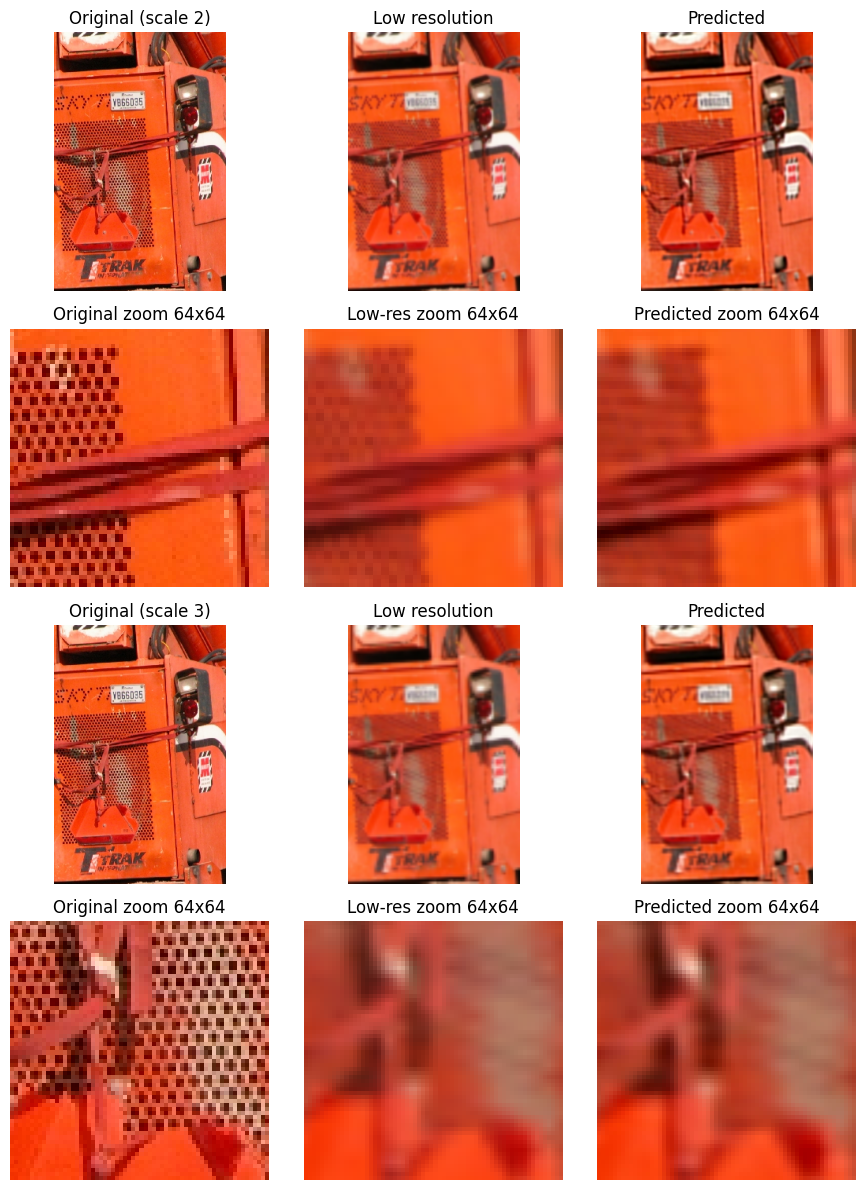

In [53]:

test_images = glob.glob("./T91_test/*.png")
if not test_images:
    raise RuntimeError("No images found in ./T91_test")

img_path = random.choice(test_images)
print("Using test image:", img_path)

hr_img_rgb = Image.open(img_path).convert("RGB")

model.eval()

scales = [2, 3]

fig, axes = plt.subplots(len(scales) * 2, 3, figsize=(9, 6 * len(scales)))

if len(scales) * 2 == 2:
    axes = np.array(axes).reshape(2, 3)

for i, scale in enumerate(scales):
    lr_img_rgb = make_low_resolution(hr_img_rgb, scale)

    hr_y = rgb_to_y(hr_img_rgb) / 255.0
    lr_y = rgb_to_y(lr_img_rgb) / 255.0

    lr_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_tensor = model(lr_tensor).clamp(0.0, 1.0)

    pred_y = pred_tensor.squeeze().cpu().numpy()

    mse = np.mean((hr_y - pred_y) ** 2)
    print(f"Scale {scale}: MSE on Y = {mse:.6f}")

    ycbcr_lr = lr_img_rgb.convert("YCbCr")
    _, cb_lr, cr_lr = ycbcr_lr.split()

    pred_y_255 = (pred_y * 255.0).clip(0, 255).astype(np.uint8)
    pred_y_img = Image.fromarray(pred_y_255, mode="L")
    pred_ycbcr_img = Image.merge("YCbCr", (pred_y_img, cb_lr, cr_lr))
    pred_rgb_img = pred_ycbcr_img.convert("RGB")

    row_full = 2 * i
    row_zoom = 2 * i + 1

    axes[row_full, 0].imshow(hr_img_rgb)
    axes[row_full, 0].set_title(f"Original (scale {scale})")
    axes[row_full, 0].axis("off")

    axes[row_full, 1].imshow(lr_img_rgb)
    axes[row_full, 1].set_title("Low resolution")
    axes[row_full, 1].axis("off")

    axes[row_full, 2].imshow(pred_rgb_img)
    axes[row_full, 2].set_title("Predicted")
    axes[row_full, 2].axis("off")

    w, h = hr_img_rgb.size
    crop_w, crop_h = 64, 64
    if w < crop_w or h < crop_h:
        x0, y0 = 0, 0
    else:
        x0 = random.randint(0, w - crop_w)
        y0 = random.randint(0, h - crop_h)
    box = (x0, y0, x0 + crop_w, y0 + crop_h)

    hr_crop = hr_img_rgb.crop(box)
    lr_crop = lr_img_rgb.crop(box)
    pred_crop = pred_rgb_img.crop(box)

    axes[row_zoom, 0].imshow(hr_crop)
    axes[row_zoom, 0].set_title("Original zoom 64x64")
    axes[row_zoom, 0].axis("off")

    axes[row_zoom, 1].imshow(lr_crop)
    axes[row_zoom, 1].set_title("Low-res zoom 64x64")
    axes[row_zoom, 1].axis("off")

    axes[row_zoom, 2].imshow(pred_crop)
    axes[row_zoom, 2].set_title("Predicted zoom 64x64")
    axes[row_zoom, 2].axis("off")

plt.tight_layout()
plt.show()